<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/Feature_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Example dataset (replace with yours)
from sklearn.datasets import load_iris
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
def transform_features(X_train, X_test, method="none"):
    if method == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    elif method == "polynomial":
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train = poly.fit_transform(X_train)
        X_test = poly.transform(X_test)

    return X_train, X_test

In [3]:
def evaluate_model(X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

In [4]:
transformations = ["none", "standard", "polynomial"]

for t in transformations:
    Xt_train, Xt_test = transform_features(X_train, X_test, method=t)
    acc = evaluate_model(Xt_train, Xt_test, y_train, y_test)
    print(f"Transformation: {t}, Accuracy: {acc:.4f}")

Transformation: none, Accuracy: 1.0000
Transformation: standard, Accuracy: 1.0000
Transformation: polynomial, Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# Apply same transformation to subsets of features
selected_features = X.columns[:2]  # first 2 features

Xt_train, Xt_test = transform_features(
    X_train[selected_features],
    X_test[selected_features],
    method="standard"
)

acc = evaluate_model(Xt_train, Xt_test, y_train, y_test)
print(f"Accuracy with selected features + transform: {acc:.4f}")

Accuracy with selected features + transform: 0.9000


In [6]:
feature_names = list(X.columns)

results = []

# Try combinations of 2 features
for combo in combinations(feature_names, 2):
    Xt_train, Xt_test = transform_features(
        X_train[list(combo)],
        X_test[list(combo)],
        method="standard"
    )

    acc = evaluate_model(Xt_train, Xt_test, y_train, y_test)
    results.append((combo, acc))

# Sort results
results = sorted(results, key=lambda x: x[1], reverse=True)

print("\nTop feature combinations:")
for combo, acc in results[:5]:
    print(f"Features: {combo}, Accuracy: {acc:.4f}")


Top feature combinations:
Features: ('sepal length (cm)', 'petal length (cm)'), Accuracy: 1.0000
Features: ('sepal length (cm)', 'petal width (cm)'), Accuracy: 1.0000
Features: ('sepal width (cm)', 'petal length (cm)'), Accuracy: 1.0000
Features: ('sepal width (cm)', 'petal width (cm)'), Accuracy: 1.0000
Features: ('petal length (cm)', 'petal width (cm)'), Accuracy: 1.0000


In [7]:
Xt_train, Xt_test = transform_features(X_train, X_test, method="standard")
acc = evaluate_model(Xt_train, Xt_test, y_train, y_test)

print(f"\nAccuracy with ALL features: {acc:.4f}")


Accuracy with ALL features: 1.0000


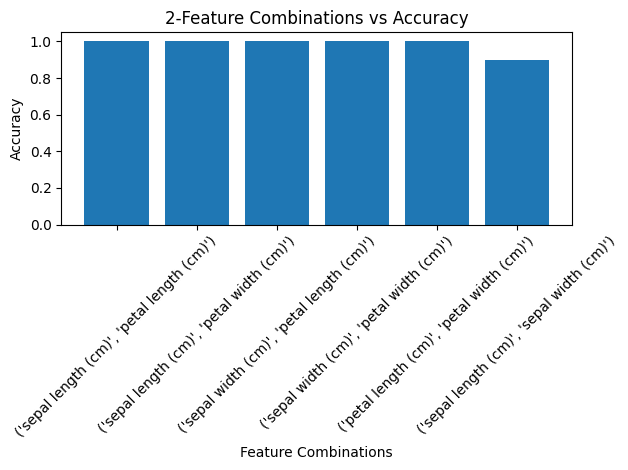

In [10]:
import matplotlib.pyplot as plt

combos = [item[0] for item in results]
accuracies = [item[1] for item in results]

plt.figure()
plt.bar(range(len(combos)), accuracies)
plt.xticks(range(len(combos)), [str(c) for c in combos], rotation=45)
plt.xlabel("Feature Combinations")
plt.ylabel("Accuracy")
plt.title("2-Feature Combinations vs Accuracy")
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

def apply_transformation(X, matrix):
    return np.dot(X, matrix)

# Example: using 2 features
features = ['sepal length (cm)', 'petal length (cm)']  # Replaced with actual columns

X_train_sel = X_train[features].values
X_test_sel = X_test[features].values

T = np.array([[2, 0], [0, 0.5]])

X_train_trans = apply_transformation(X_train_sel, T)
X_test_trans = apply_transformation(X_test_sel, T)

acc = evaluate_model(X_train_trans, X_test_trans, y_train, y_test)
print("Accuracy after transformation:", acc)

Accuracy after transformation: 1.0


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# Apply transformation AFTER scaling
X_train_final = apply_transformation(X_train_scaled, T)
X_test_final = apply_transformation(X_test_scaled, T)

acc = evaluate_model(X_train_final, X_test_final, y_train, y_test)
print("Accuracy (Normalize + Transform):", acc)

Accuracy (Normalize + Transform): 0.8666666666666667


In [15]:
# Example alternative features
features_alt = ['sepal width (cm)', 'petal width (cm)']  # Replaced with actual dataset columns

X_train_alt = X_train[features_alt]
X_test_alt = X_test[features_alt]

acc = evaluate_model(X_train_alt, X_test_alt, y_train, y_test)
print("Accuracy with new features:", acc)

Accuracy with new features: 1.0


In [16]:
def z_score_normalize(train, test):
    mean = train.mean(axis=0)
    std = train.std(axis=0)

    train_norm = (train - mean) / std
    test_norm = (test - mean) / std

    return train_norm, test_norm

X_train_z, X_test_z = z_score_normalize(X_train_sel, X_test_sel)

acc = evaluate_model(X_train_z, X_test_z, y_train, y_test)
print("Accuracy with Z-score normalization:", acc)

Accuracy with Z-score normalization: 1.0


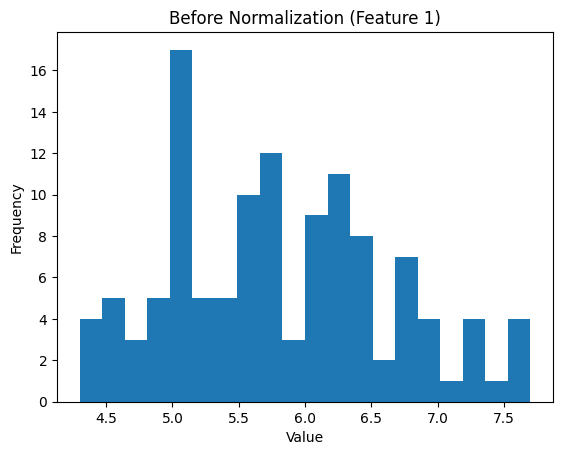

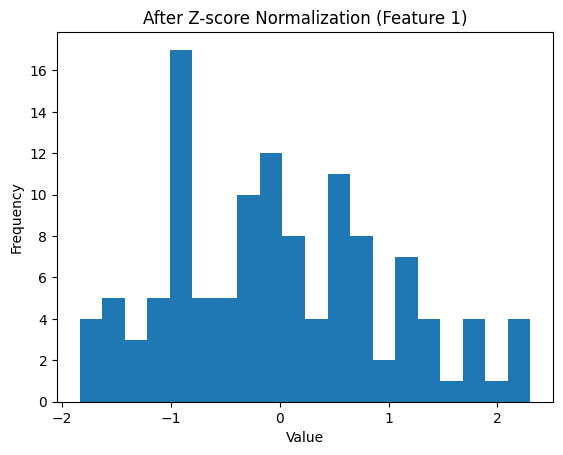

In [17]:
import matplotlib.pyplot as plt

# Before normalization
plt.figure()
plt.hist(X_train_sel[:, 0], bins=20)
plt.title("Before Normalization (Feature 1)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# After normalization
plt.figure()
plt.hist(X_train_z[:, 0], bins=20)
plt.title("After Z-score Normalization (Feature 1)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()